# 04 - Content NLP Analysis

Running NLP analysis pipeline...


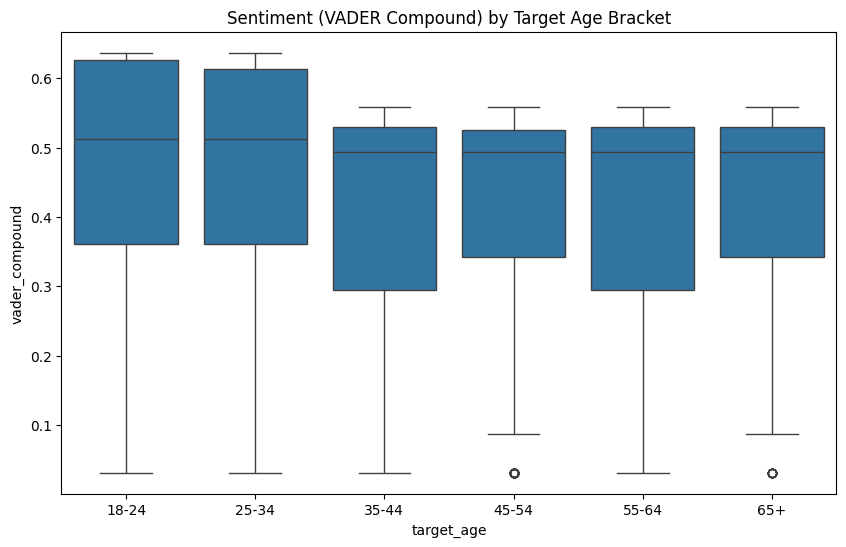

/var/folders/p8/r0pgx2r50296zxc34f9ftgjm0000gn/T/ipykernel_73564/4214159657.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=nlp_df, x='target_age', y='fk_grade', errorbar=None, palette='coolwarm')


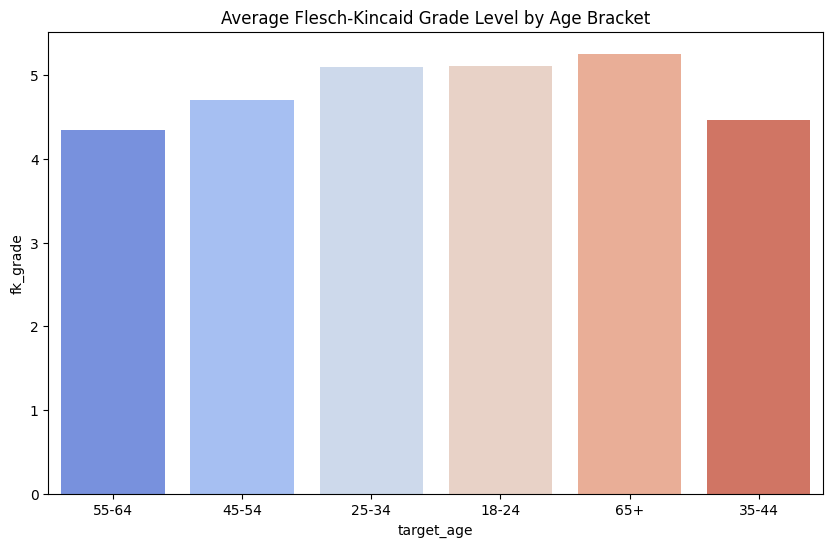

/var/folders/p8/r0pgx2r50296zxc34f9ftgjm0000gn/T/ipykernel_73564/4214159657.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=risk_summary, x='target_age', y='risk_keyword_count', palette='Reds')


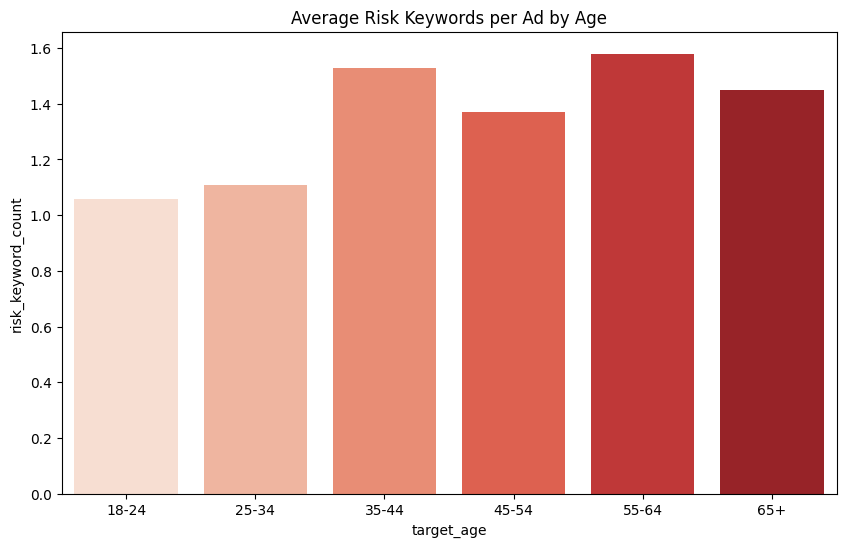

In [1]:
import sys
sys.path.append('..')
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scripts.nlp_analysis import analyze_text

meta_df = pd.read_csv('../data/processed/meta_ads_clean.csv')

nlp_df = analyze_text(meta_df, 'body')

# Plot Sentiment by Age
plt.figure(figsize=(10,6))
sns.boxplot(data=nlp_df, x='target_age', y='vader_compound', order=['18-24', '25-34', '35-44', '45-54', '55-64', '65+'])
plt.title('Sentiment (VADER Compound) by Target Age Bracket')
plt.savefig('../figures/sentiment_by_age.png')
plt.show()

# Readability by Age
plt.figure(figsize=(10,6))
sns.barplot(data=nlp_df, x='target_age', y='fk_grade', errorbar=None, palette='coolwarm')
plt.title('Average Flesch-Kincaid Grade Level by Age Bracket')
plt.savefig('../figures/readability_by_age.png')
plt.show()

# Risk Keywords
risk_summary = nlp_df.groupby('target_age')['risk_keyword_count'].mean().reset_index()
plt.figure(figsize=(10,6))
sns.barplot(data=risk_summary, x='target_age', y='risk_keyword_count', palette='Reds')
plt.title('Average Risk Keywords per Ad by Age')
plt.savefig('../figures/risk_keywords_by_age.png')
plt.show()
